# **Portfolio:** Mario Casanova — Data Science & Analytics Portfolio
## **Case Study:** Continental Philosophy & Dialectical Knowledge Graphs

---
*Note: this notebook formalizes one reading of Hegelian phenomenology as a directed graph. I hand-authored the semantic triplets below to encode an interpretive choice about which categories sublate (*Aufhebung*) into which, and eigenvector centrality then **describes the positional structure of that encoding**, nothing more. Read honestly, the result is a statement about the graph I built, not an empirical discovery about Hegel's text as an independent object. That isn't a limitation to apologize for: the point was never to extract meaning from the text on its own; it's to make a reading explicit and inspectable, which is exactly what a network instrument is good for and exactly what it cannot do if you mistake its output for something the text said on its own.*


In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.style.use('dark_background')

### 1. What I Encoded, by Hand
No automated NLP extraction happens here. Instead, the prose passage below is illustrative; the triplets that follow are typed directly, as my explicit encoding of a reading of the dialectic into (Subject, Predicate, Object) form. Making that encoding visible *as code* is the point: every edge is a choice you can inspect, contest, or revise.


In [2]:
# Textual Corpus (Simulated Ingestion)
"""
Being in itself is pure and indeterminate, but in its immediacy it inevitably 
transitions toward Nothing. This immediacy of Being and Nothing finds its truth in 
Becoming. Similarly, the Master risks his life for recognition, establishing the 
paradigm of Lordship. The Slave shuns death and embraces Labor, transforming 
objective Nature. The Slave's Labor transcends the stagnant Lordship of the Master. 
Through Aufhebung, Labor and Lordship converge in absolute Self-knowledge. 
Reason overcomes subjective Self-knowledge to reach Spirit.
"""

# Structured Extraction of Organic Triplets (Subject, Predicate, Object)
triplets = [
    ("Being", "transitions_toward", "Nothing"),
    ("Being", "confluences_in", "Becoming"),
    ("Nothing", "confluences_in", "Becoming"),
    ("Master", "establishes", "Lordship"),
    ("Slave", "embraces", "Labor"),
    ("Slave", "transforms", "Nature"),
    ("Labor", "transcends", "Lordship"),
    ("Labor", "aufhebung_toward", "Self_knowledge"),
    ("Lordship", "aufhebung_toward", "Self_knowledge"),
    ("Reason", "overcomes", "Self_knowledge"),
    ("Reason", "reaches", "Spirit")
]

df_triplets = pd.DataFrame(triplets, columns=["Subject", "Predicate", "Object"])
df_triplets

,Subject,Predicate,Object
0,Being,transitions_toward,Nothing
1,Being,confluences_in,Becoming
2,Nothing,confluences_in,Becoming
3,Master,establishes,Lordship
4,Slave,embraces,Labor
5,Slave,transforms,Nature
6,Labor,transcends,Lordship
7,Labor,aufhebung_toward,Self_knowledge
8,Lordship,aufhebung_toward,Self_knowledge
9,Reason,overcomes,Self_knowledge


### 2. From Triplets to Topology
I turn the relational tuples into a Directed Graph ($G=(V,E)$) with `NetworkX`, in order to audit where the contradictions I encoded actually converge.


In [3]:
G = nx.DiGraph()

# Add directional edges based on triplets
for _, row in df_triplets.iterrows():
    G.add_edge(row['Subject'], row['Object'], relation=row['Predicate'])

print(f"[*] Network Topology: {G.number_of_nodes()} Dialectical Nodes, {G.number_of_edges()} Logical Edges.")

[*] Network Topology: 11 Dialectical Nodes, 11 Logical Edges.


### 3. Centrality Measures the Encoding, Not the Text
Eigenvector centrality ($Ax = \lambda x$) scores a node by the weighted influence of whatever points to it. Applied here, it ranks each node by its position in **the graph I encoded** — it does not measure a property of Hegel's system independent of that encoding. Concretely, my edge list routes *Aufhebung* toward a single convergence point, so centrality concentrating there is not a discovery about the text; it is the arithmetic confirming a choice I had already made, now visible as a number instead of buried in a diagram.


In [4]:
# Numerical Computation of Eigenvector Centrality (Iterating the power method)
eigen_centrality = nx.eigenvector_centrality(G, max_iter=1000, tol=1e-06)

# Normalization to Logical Load scale (0 to 100)
df_centrality = pd.DataFrame(list(eigen_centrality.items()), columns=['Logical_Category', 'Vector_Weight'])
df_centrality['Vector_Weight'] = (df_centrality['Vector_Weight'] / df_centrality['Vector_Weight'].max()) * 100

df_centrality.sort_values(by='Vector_Weight', ascending=False).reset_index(drop=True)

,Logical_Category,Vector_Weight
0,Self_knowledge,100.000000
1,Becoming,0.402685
2,Lordship,0.402685
3,Nothing,0.001082
4,Labor,0.001082
5,Nature,0.001082
6,Spirit,0.001082
7,Being,0.000001
8,Master,0.000001
9,Slave,0.000001


### 4. What the Picture Confirms (and Doesn't)
I render the structure with node radii linearly proportional to eigenvector centrality (`node_size = centrality × 6000`, a deterministic map, so no randomness sneaks in here). That determinism is exactly why the picture says nothing the centrality table hasn't already said: `Self_knowledge` dominates with a normalized score of 100, because it is the graph's one true **sink** (`Labor`, `Lordship`, and `Reason` all point into it, and it has no out-edges of its own). Every other node, `Becoming` included at 0.40, scores orders of magnitude lower. None of that measures the categories' actual importance; it reflects the convergence edges I chose to draw.

*Caveat on the instrument:* I'd flag this before anyone reads too much into the picture. Eigenvector centrality degenerates toward sinks on a directed graph like this one, which is exactly why most nodes collapse toward ~0. PageRank or Katz centrality, which add a damping or teleportation term, would spread the scores out more honestly and are the better choice the moment the question turns comparative rather than illustrative.


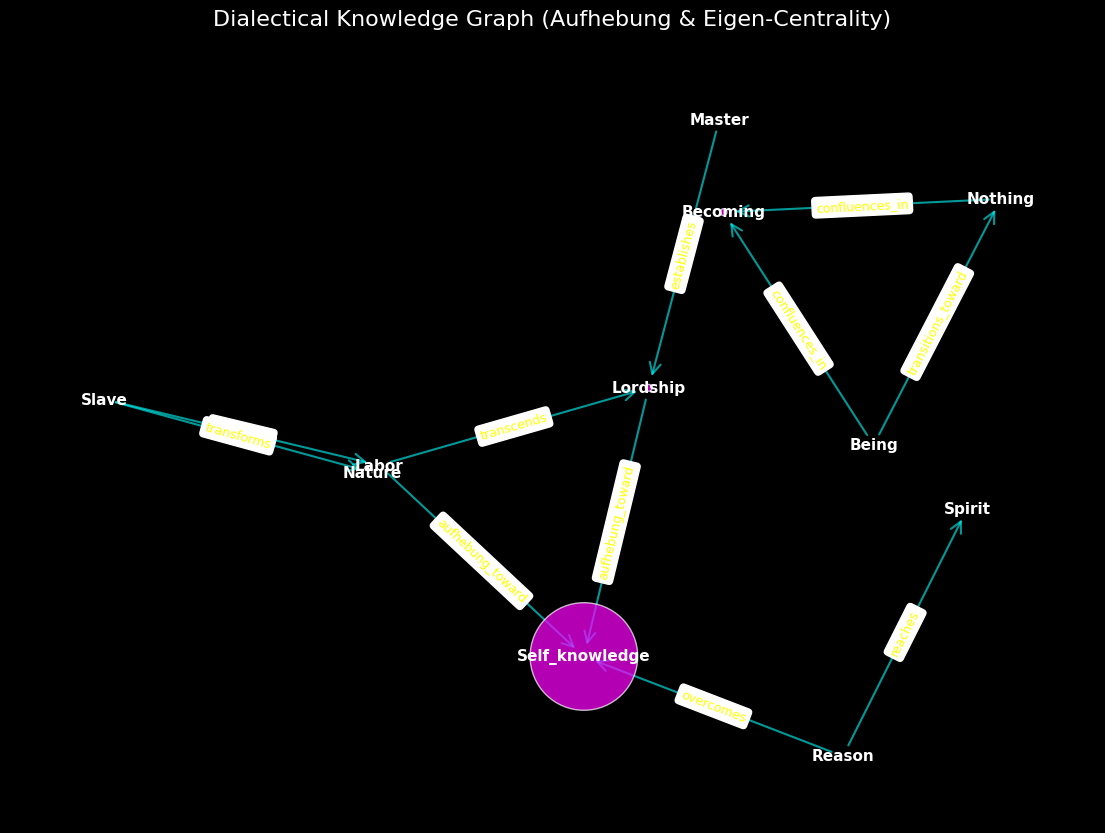

In [5]:
plt.figure(figsize=(14, 10))

# Use eigenvector scaling for node size
node_sizes = [eigen_centrality[node] * 6000 for node in G.nodes()]

# Kamada-Kawai layout algorithm (optimal for directed force displays)
pos = nx.kamada_kawai_layout(G)

nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color="magenta", alpha=0.7, edgecolors="white")
nx.draw_networkx_edges(G, pos, edge_color="cyan", arrowsize=20, arrowstyle="->", width=1.5, alpha=0.6)
nx.draw_networkx_labels(G, pos, font_size=11, font_color="white", font_weight="bold")

# Relational predicate labels
edge_labels = nx.get_edge_attributes(G, 'relation')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color="yellow", font_size=9, label_pos=0.5)

plt.title("Dialectical Knowledge Graph (Aufhebung & Eigen-Centrality)", fontsize=16, pad=20, color="white")
plt.axis("off")
plt.show()